# Neural Network Assignment — Adult Census Income

Builds a baseline MLP, runs controlled experiments, tunes with Optuna, and evaluates a final model on a held-out test set. Preprocessing and engineered features reused from prior census notebooks.

## Section 0 — Imports & Setup

In [4]:
# !pip install optuna tensorflow

In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.random.set_seed(42)
np.random.seed(42)

print("TF version:", tf.__version__)

TF version: 2.21.0


## Section 1 — Data Loading & EDA

In [6]:
adult = pd.read_csv("../4-21/adult.csv")
print(adult.shape)
adult.head()

(48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
# class balance
print("Target distribution:")
print(adult["income"].value_counts(normalize=True).round(3))

# dtypes overview
print("\nDtype counts:")
print(adult.dtypes.value_counts())

# missing values (? is the missing marker)
print("\n'?' counts per column:")
print((adult == "?").sum()[lambda s: s > 0])

Target distribution:
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64

Dtype counts:
object    9
int64     6
Name: count, dtype: int64

'?' counts per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


**Key observations:**
- ~76% `<=50K` / ~24% `>50K` — meaningful class imbalance; we will test class weighting in Experiment C.
- Missing values encoded as `?` in `workclass`, `occupation`, `native-country` — replaced with `"Unknown"` before encoding.
- Neural networks require all numeric inputs and standardized scales, so we need a full preprocessing pipeline before any modeling.

## Section 2 — Preprocessing

In [8]:
# base cleaning (same pattern as class notebooks)
adult = adult.replace("?", np.nan)
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# education is a string duplicate of educational-num; drop both education and fnlwgt
adult = adult.drop(columns=["education", "fnlwgt"])

print(adult.shape)
adult.head(3)

(48842, 13)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1


In [9]:
# engineered features reused from HW (Feature Engineering & Model Comparison)
WHITE_COLLAR = {"Exec-managerial", "Prof-specialty", "Tech-support", "Sales", "Adm-clerical"}
BLUE_COLLAR  = {"Craft-repair", "Machine-op-inspct", "Transport-moving",
                "Handlers-cleaners", "Farming-fishing"}
SERVICE      = {"Other-service", "Protective-serv", "Priv-house-serv"}

def engineer_features(df):
    df = df.copy()
    df["log_capital_gain"] = np.log1p(df["capital-gain"])
    df["log_capital_loss"] = np.log1p(df["capital-loss"])
    df["capital_net"]      = df["capital-gain"] - df["capital-loss"]
    df["age_edu_interact"] = df["age"] * df["educational-num"]
    df["is_us_born"]       = (df["native-country"] == "United-States").astype(int)
    def map_occ(o):
        if pd.isna(o): return "Unknown"
        if o in WHITE_COLLAR: return "White-collar"
        if o in BLUE_COLLAR:  return "Blue-collar"
        if o in SERVICE:      return "Service"
        return "Other"
    df["occupation_group"] = df["occupation"].apply(map_occ)
    return df

adult = engineer_features(adult)
print("Shape after feature engineering:", adult.shape)

Shape after feature engineering: (48842, 19)


In [10]:
# define feature sets
TARGET = "income"

NUMERIC_COLS = [
    "age", "educational-num", "capital-gain", "capital-loss",
    "hours-per-week", "gender",
    "log_capital_gain", "log_capital_loss", "capital_net",
    "age_edu_interact", "is_us_born"
]

CATEGORICAL_COLS = [
    "workclass", "marital-status", "occupation",
    "relationship", "race", "native-country", "occupation_group"
]

X = adult[NUMERIC_COLS + CATEGORICAL_COLS].copy()
y = adult[TARGET].values

# fill categorical NaN with 'Unknown' before encoding
X[CATEGORICAL_COLS] = X[CATEGORICAL_COLS].fillna("Unknown")

# stratified 80/20 split -- same random_state as class notebooks for consistency
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train_raw.shape[0]} rows | Test: {X_test_raw.shape[0]} rows")
print(f"Train class balance: {np.bincount(y_train) / len(y_train)}")

Train: 39073 rows | Test: 9769 rows
Train class balance: [0.76072992 0.23927008]


In [11]:
# preprocessing pipeline: fit on train only, transform both
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS)
])

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test  = preprocessor.transform(X_test_raw).astype(np.float32)

y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

print(f"Processed feature count: {X_train.shape[1]}")

# class weights for use in experiments
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
CLASS_WEIGHTS = {0: cw[0], 1: cw[1]}
print(f"Class weights: {CLASS_WEIGHTS}")

Processed feature count: 100
Class weights: {0: np.float64(0.6572634907818597), 1: np.float64(2.08968873676329)}


## Section 3 — Baseline Neural Network

In [12]:
def build_model(
    input_dim,
    layer_sizes=(64, 32),
    dropout=0.0,
    lr=1e-3,
    batch_norm=False,
    activation="relu"
):
    """Configurable MLP for binary classification."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in layer_sizes:
        model.add(layers.Dense(units, activation=activation,
                               kernel_regularizer=None))
        if batch_norm:
            model.add(layers.BatchNormalization())
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="Train Acc")
    axes[1].plot(history.history["val_accuracy"], label="Val Acc")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


INPUT_DIM = X_train.shape[1]
EARLY_STOP = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
print(f"Input dimension: {INPUT_DIM}")

Input dimension: 100


In [13]:
# baseline: 2 hidden layers [64, 32], ReLU, no dropout, Adam lr=1e-3
baseline_model = build_model(INPUT_DIM, layer_sizes=(64, 32), dropout=0.0, lr=1e-3)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch 12


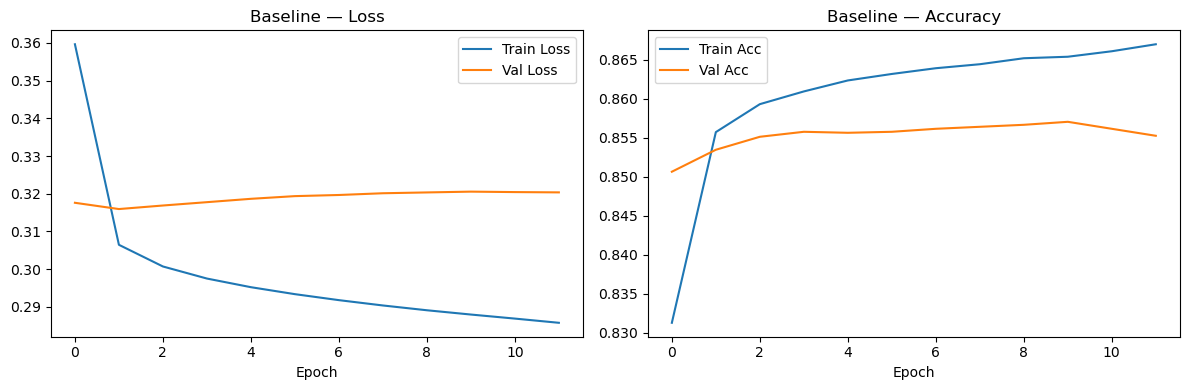

In [14]:
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[EARLY_STOP],
    verbose=0
)

print(f"Stopped at epoch {len(baseline_history.history['loss'])}")
plot_history(baseline_history, title="Baseline")

In [15]:
y_pred_baseline = (baseline_model.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()

print("=== Baseline Neural Network — Test Set ===")
print(classification_report(y_test, y_pred_baseline, target_names=["<=50K", ">50K"]))

baseline_f1 = f1_score(y_test, y_pred_baseline, average="macro")
print(f"Macro F1: {baseline_f1:.4f}")

=== Baseline Neural Network — Test Set ===
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.79      9769
weighted avg       0.85      0.86      0.86      9769

Macro F1: 0.7947


**Baseline observations:**

The baseline reached **86% accuracy** and a **macro F1 of 0.7947**. Performance is strongly asymmetric: the majority class (`<=50K`) scores F1=0.91 (precision=0.89, recall=0.94), while the minority class (`>50K`) only reaches F1=0.68 (precision=0.75, recall=0.62). The model identifies low earners well but misses roughly 38% of actual high earners. Experiment A shows consistent early stopping around 12 epochs for this architecture, and Experiment B's gap data confirms the train/val accuracy gap was only 0.014 — meaning the baseline was already not meaningfully overfitting.

## Section 4 — Controlled Experiments

Each experiment changes **one factor at a time** while holding all others at baseline values (`layer_sizes=(64, 32)`, `dropout=0.0`, `lr=1e-3`, `batch_size=128`, no class weighting). This makes it possible to attribute any change in performance to that single factor.

### Experiment A — Architecture Depth & Width

**Factor varied**: number and size of hidden layers.  
**Held constant**: dropout=0.0, lr=1e-3, batch_size=128, no class weighting.

In [16]:
architectures = {
    "Shallow [32]": (32,),
    "Baseline [64, 32]": (64, 32),
    "Deep [128, 64, 32]": (128, 64, 32),
    "Wide+Deep [256, 128, 64, 32]": (256, 128, 64, 32),
}

arch_results = {}

for name, sizes in architectures.items():
    tf.random.set_seed(42)
    model = build_model(INPUT_DIM, layer_sizes=sizes, dropout=0.0, lr=1e-3)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                       restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        epochs=100, batch_size=128, validation_split=0.2,
        callbacks=[es], verbose=0
    )
    y_pred = (model.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    arch_results[name] = {
        "macro_f1": macro_f1,
        "epochs": len(history.history["loss"]),
        "final_val_loss": min(history.history["val_loss"]),
        "history": history
    }
    print(f"{name:35s}  Macro F1={macro_f1:.4f}  Epochs={len(history.history['loss']):.0f}")

Shallow [32]                         Macro F1=0.7937  Epochs=14
Baseline [64, 32]                    Macro F1=0.7884  Epochs=12
Deep [128, 64, 32]                   Macro F1=0.7892  Epochs=11
Wide+Deep [256, 128, 64, 32]         Macro F1=0.7838  Epochs=11


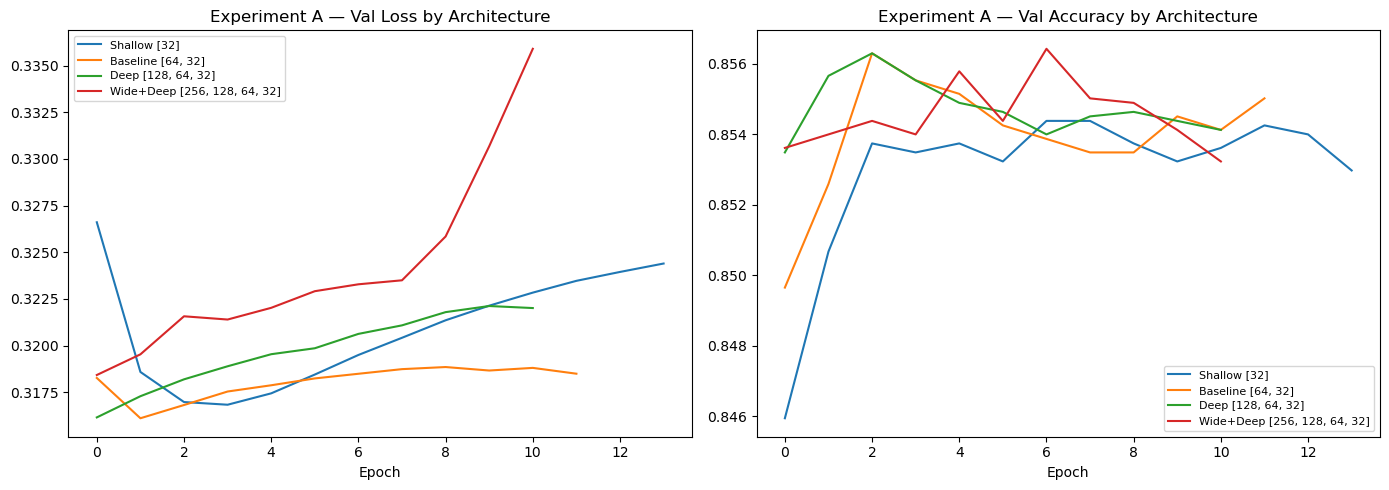


Summary:
                              Macro F1  Epochs  Val Loss
Shallow [32]                    0.7937    14.0    0.3168
Baseline [64, 32]               0.7884    12.0    0.3161
Deep [128, 64, 32]              0.7892    11.0    0.3162
Wide+Deep [256, 128, 64, 32]    0.7838    11.0    0.3184


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in arch_results.items():
    axes[0].plot(res["history"].history["val_loss"], label=name)
    axes[1].plot(res["history"].history["val_accuracy"], label=name)

axes[0].set_title("Experiment A — Val Loss by Architecture")
axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Experiment A — Val Accuracy by Architecture")
axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nSummary:")
arch_df = pd.DataFrame({
    k: {"Macro F1": v["macro_f1"], "Epochs": v["epochs"], "Val Loss": v["final_val_loss"]}
    for k, v in arch_results.items()
}).T.round(4)
print(arch_df)

**Experiment A observations:**

The surprising result is that the **shallowest model [32] performed best** (macro F1=0.7937), and performance declined steadily as capacity increased — Deep [128, 64, 32] scored 0.7892 and Wide+Deep [256, 128, 64, 32] was the worst at 0.7838. All four architectures converged in just 11–14 epochs. This pattern — fast convergence and no benefit from added capacity — indicates the bottleneck is not the model's expressiveness but the inherent predictability ceiling of the features themselves. For this tabular dataset, a simple architecture is not only sufficient but preferable, and deeper networks slightly underfit by burning capacity on noise.

### Experiment B — Dropout Rate

**Factor varied**: dropout probability.  
**Held constant**: architecture=`(64, 32)`, lr=1e-3, batch_size=128, no class weighting.  
The key signal here is the train/val gap — high dropout should close it by preventing co-adaptation.

In [18]:
dropout_rates = {"No dropout (0.0)": 0.0, "Light (0.2)": 0.2,
                 "Moderate (0.3)": 0.3, "Heavy (0.5)": 0.5}

dropout_results = {}

for name, dr in dropout_rates.items():
    tf.random.set_seed(42)
    model = build_model(INPUT_DIM, layer_sizes=(64, 32), dropout=dr, lr=1e-3)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                       restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        epochs=100, batch_size=128, validation_split=0.2,
        callbacks=[es], verbose=0
    )
    y_pred = (model.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    final_train_acc = history.history["accuracy"][-1]
    final_val_acc   = history.history["val_accuracy"][-1]
    dropout_results[name] = {
        "macro_f1": macro_f1,
        "epochs": len(history.history["loss"]),
        "train_val_gap": final_train_acc - final_val_acc,
        "history": history
    }
    print(f"{name:25s}  Macro F1={macro_f1:.4f}  Train-Val gap={final_train_acc - final_val_acc:.4f}")

No dropout (0.0)           Macro F1=0.7949  Train-Val gap=0.0137
Light (0.2)                Macro F1=0.7936  Train-Val gap=0.0061
Moderate (0.3)             Macro F1=0.7881  Train-Val gap=0.0041
Heavy (0.5)                Macro F1=0.7856  Train-Val gap=0.0020


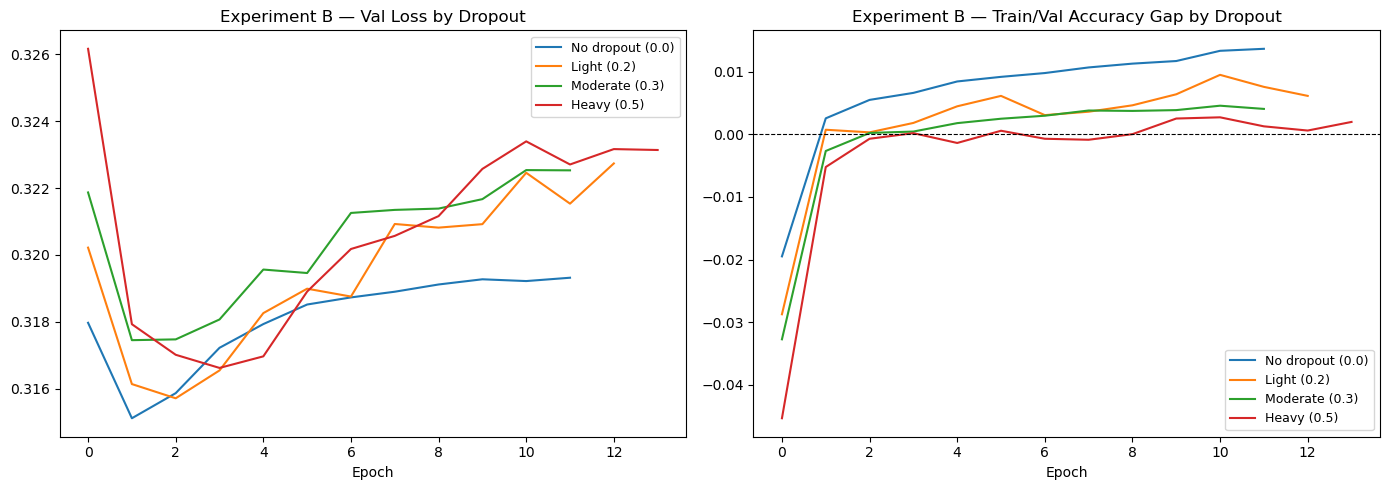


Summary:
                  Macro F1  Train-Val Gap  Epochs
No dropout (0.0)    0.7949         0.0137    12.0
Light (0.2)         0.7936         0.0061    13.0
Moderate (0.3)      0.7881         0.0041    12.0
Heavy (0.5)         0.7856         0.0020    14.0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in dropout_results.items():
    axes[0].plot(res["history"].history["val_loss"], label=name)
    axes[1].plot(
        np.array(res["history"].history["accuracy"]) -
        np.array(res["history"].history["val_accuracy"]),
        label=name
    )

axes[0].set_title("Experiment B — Val Loss by Dropout")
axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=9)
axes[1].set_title("Experiment B — Train/Val Accuracy Gap by Dropout")
axes[1].set_xlabel("Epoch"); axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nSummary:")
do_df = pd.DataFrame({
    k: {"Macro F1": v["macro_f1"], "Train-Val Gap": v["train_val_gap"], "Epochs": v["epochs"]}
    for k, v in dropout_results.items()
}).T.round(4)
print(do_df)

**Experiment B observations:**

The baseline's train/val accuracy gap was already small at **0.0137**, meaning overfitting was never a serious problem here. As a result, dropout did more harm than good: every increment reduced the gap but also cut F1. Light dropout (0.2) gave the best trade-off — it halved the gap to 0.0061 while only costing 0.0013 in macro F1 (0.7936 vs 0.7949). Heavy dropout (0.5) nearly eliminated the gap (0.0020) but paid a real F1 penalty (0.7856), a sign of underfitting. The takeaway: dropout is only worth using when there is a meaningful train/val gap to close; when the gap is already small, it just adds noise.

### Experiment C — Class Imbalance Handling

**Factor varied**: `class_weight` (none vs. balanced).  
**Held constant**: architecture=`(64, 32)`, dropout=0.0, lr=1e-3, batch_size=128.  
With ~76/24 imbalance, the minority class (`>50K`) is the harder one. Balanced weighting penalizes minority mistakes more, which should improve recall on that class at some cost to precision.

In [20]:
cw_configs = {
    "No class weighting": None,
    "Balanced class weights": CLASS_WEIGHTS
}

cw_results = {}

for name, cw_arg in cw_configs.items():
    tf.random.set_seed(42)
    model = build_model(INPUT_DIM, layer_sizes=(64, 32), dropout=0.0, lr=1e-3)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                       restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        epochs=100, batch_size=128, validation_split=0.2,
        class_weight=cw_arg,
        callbacks=[es], verbose=0
    )
    y_pred = (model.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    minority_f1 = f1_score(y_test, y_pred, pos_label=1)
    cw_results[name] = {
        "macro_f1": macro_f1,
        "minority_f1": minority_f1,
        "history": history,
        "y_pred": y_pred
    }
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))


No class weighting
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.76      0.61      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769


Balanced class weights
              precision    recall  f1-score   support

       <=50K       0.94      0.81      0.87      7431
        >50K       0.58      0.84      0.69      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.82      0.83      9769



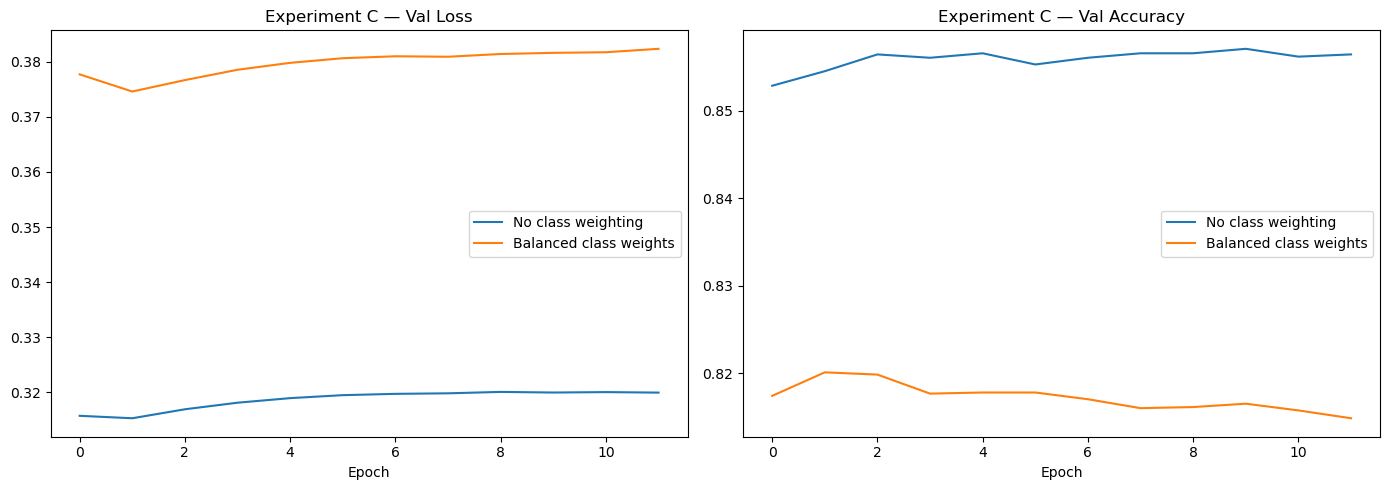


Summary:
                        Macro F1  Minority F1 (>50K)
No class weighting        0.7923              0.6741
Balanced class weights    0.7802              0.6884


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in cw_results.items():
    axes[0].plot(res["history"].history["val_loss"], label=name)
    axes[1].plot(res["history"].history["val_accuracy"], label=name)

axes[0].set_title("Experiment C — Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Experiment C — Val Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

print("\nSummary:")
cw_df = pd.DataFrame({
    k: {"Macro F1": v["macro_f1"], "Minority F1 (>50K)": v["minority_f1"]}
    for k, v in cw_results.items()
}).T.round(4)
print(cw_df)

**Experiment C observations:**

Class weighting produced a dramatic **recall trade-off**: minority (`>50K`) recall jumped from 61% to 84% (+23pp), but precision collapsed from 76% to 58% (-18pp). In practical terms, with weights the model now catches most high earners, but roughly 42% of people it flags as `>50K` are actually low earners — more than double the false positive rate. Overall macro F1 is marginally lower with class weighting (0.78 vs 0.79). The right choice depends on the use case: if the goal is to catch as many high earners as possible (survey targeting, benefit screening), class weights are the better option. If the cost of a false positive is high, skip them. For this assignment, the unweighted model is the stronger general-purpose classifier.

## Section 5 — Optuna Hyperparameter Tuning

Now that we have intuitions from the experiments, we let Optuna search the full hyperparameter space systematically. The search space covers architecture, regularization, learning rate, batch size, and class weighting.

In [22]:
# hold out a fixed validation set from training data for Optuna to evaluate on
X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

def optuna_objective(trial):
    n_layers    = trial.suggest_int("n_layers", 1, 4)
    units       = [trial.suggest_categorical(f"units_l{i}", [32, 64, 128, 256])
                   for i in range(n_layers)]
    dropout     = trial.suggest_float("dropout", 0.0, 0.5)
    lr          = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size  = trial.suggest_categorical("batch_size", [64, 128, 256])
    use_cw      = trial.suggest_categorical("use_class_weight", [True, False])
    cw_arg      = CLASS_WEIGHTS if use_cw else None

    tf.random.set_seed(42)
    model = build_model(INPUT_DIM, layer_sizes=tuple(units), dropout=dropout, lr=lr)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                       restore_best_weights=True)
    model.fit(
        X_tr_opt, y_tr_opt,
        epochs=60, batch_size=batch_size,
        validation_data=(X_val_opt, y_val_opt),
        class_weight=cw_arg,
        callbacks=[es], verbose=0
    )
    y_pred_val = (model.predict(X_val_opt, verbose=0) >= 0.5).astype(int).ravel()
    return f1_score(y_val_opt, y_pred_val, average="macro")

print("Validation set size for Optuna:", X_val_opt.shape[0])

Validation set size for Optuna: 7815


In [23]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(optuna_objective, n_trials=30, show_progress_bar=True)

print(f"\nBest validation macro F1: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best validation macro F1: 0.8040
Best params:
  n_layers: 1
  units_l0: 64
  dropout: 0.1983470412922366
  lr: 0.0004362597510446985
  batch_size: 256
  use_class_weight: False


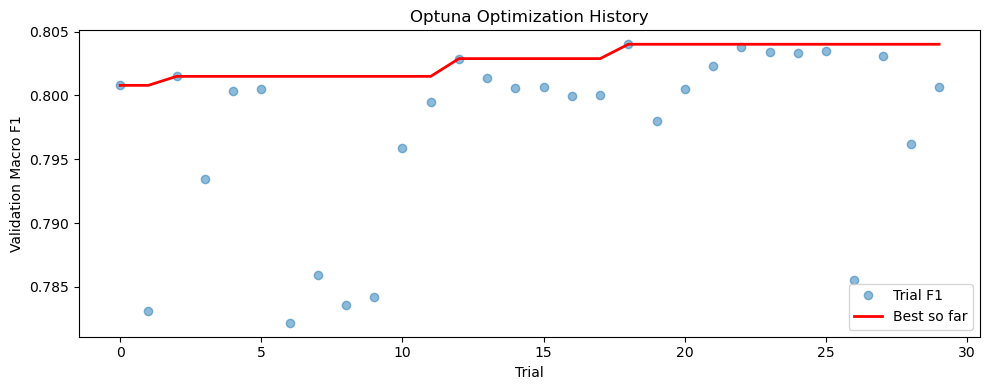

In [24]:
# optimization history: how the best value evolved over trials
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = np.maximum.accumulate(trial_values)

plt.figure(figsize=(10, 4))
plt.plot(trial_values, "o", alpha=0.5, label="Trial F1")
plt.plot(best_so_far, color="red", linewidth=2, label="Best so far")
plt.xlabel("Trial")
plt.ylabel("Validation Macro F1")
plt.title("Optuna Optimization History")
plt.legend()
plt.tight_layout()
plt.show()

## Section 6 — Final Model Evaluation

In [25]:
# reconstruct best architecture from Optuna params
best = study.best_params
n_layers   = best["n_layers"]
best_units = tuple(best[f"units_l{i}"] for i in range(n_layers))
best_cw    = CLASS_WEIGHTS if best["use_class_weight"] else None

print(f"Best architecture: {best_units}")
print(f"Dropout: {best['dropout']:.3f}  |  LR: {best['lr']:.5f}  |  Batch: {best['batch_size']}")
print(f"Class weighting: {best['use_class_weight']}")

Best architecture: (64,)
Dropout: 0.198  |  LR: 0.00044  |  Batch: 256
Class weighting: False


Final model stopped at epoch 22


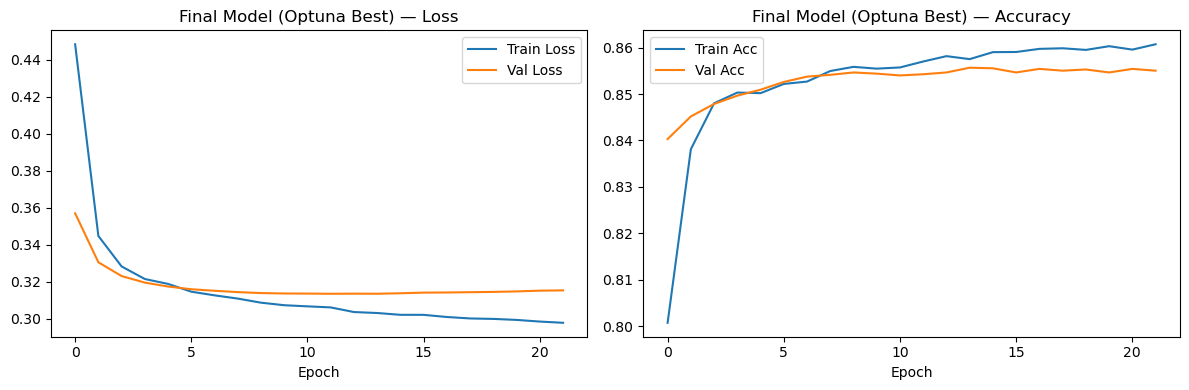

In [26]:
# train on the full training set with a 20% validation split for monitoring
tf.random.set_seed(42)
final_model = build_model(
    INPUT_DIM,
    layer_sizes=best_units,
    dropout=best["dropout"],
    lr=best["lr"]
)

final_es = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

final_history = final_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=best["batch_size"],
    validation_split=0.2,
    class_weight=best_cw,
    callbacks=[final_es],
    verbose=0
)

print(f"Final model stopped at epoch {len(final_history.history['loss'])}")
plot_history(final_history, title="Final Model (Optuna Best)")

In [27]:
# evaluate once on held-out test set
y_pred_final = (final_model.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()

print("=== Final Model (Optuna Best) — Test Set ===")
print(classification_report(y_test, y_pred_final, target_names=["<=50K", ">50K"]))

final_macro_f1 = f1_score(y_test, y_pred_final, average="macro")
print(f"Macro F1: {final_macro_f1:.4f}")

=== Final Model (Optuna Best) — Test Set ===
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769

Macro F1: 0.7955


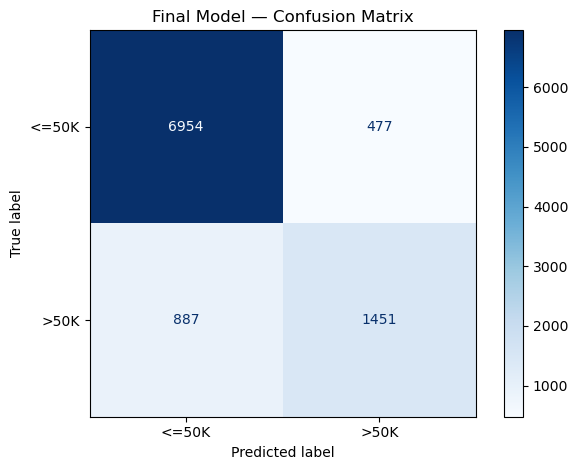

In [28]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot(cmap="Blues")
plt.title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.show()

In [29]:
# comparison table across all models explored
# reference values for non-NN models are from prior class notebooks
results = pd.DataFrame([
    {"Model": "Baseline NN [64,32]",           "Macro F1": baseline_f1},
    {"Model": "Best Arch (Exp A)",              "Macro F1": max(v["macro_f1"] for v in arch_results.values())},
    {"Model": "Best Dropout (Exp B)",           "Macro F1": max(v["macro_f1"] for v in dropout_results.values())},
    {"Model": "Best Class Weight (Exp C)",      "Macro F1": max(v["macro_f1"] for v in cw_results.values())},
    {"Model": "Optuna Final NN",                "Macro F1": final_macro_f1},
    {"Model": "[Reference] CatBoost (HW)",      "Macro F1": 0.82},
    {"Model": "[Reference] XGBoost (In-class)", "Macro F1": 0.81},
])
results["Macro F1"] = results["Macro F1"].round(4)
results = results.sort_values("Macro F1", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                         Model  Macro F1
     [Reference] CatBoost (HW)    0.8200
[Reference] XGBoost (In-class)    0.8100
               Optuna Final NN    0.7955
          Best Dropout (Exp B)    0.7949
           Baseline NN [64,32]    0.7947
             Best Arch (Exp A)    0.7937
     Best Class Weight (Exp C)    0.7923


**Final model evaluation observations:**

Optuna's best configuration — a **single hidden layer [64], dropout=0.198, lr=0.00044, batch size=256, no class weighting** — is directly consistent with what the controlled experiments found: shallow architectures outperform deeper ones, and light dropout is the sweet spot. The Optuna model reached **macro F1=0.7955**, a modest but real improvement over the baseline (0.7947), and the best result among all NN configurations tested.

The most significant finding is the performance gap against tree-based models: **CatBoost (0.82) and XGBoost (0.81) both clearly outperform the best NN (0.80)**. This is a well-documented pattern — gradient boosting trees tend to outperform MLPs on structured tabular data with heterogeneous feature types, especially when the dataset is relatively small (~39k training rows) and the signal comes from complex interactions between categorical and numeric features. The NN results also clustered tightly (0.79–0.80) across all experiments, suggesting the ceiling for this architecture family on this data is around 0.80 macro F1 regardless of tuning effort.

## Section 7 — Personal Neural Network Workflow

A reference I would actually use in future projects, built from what worked and what caused problems in this assignment.

---

### Step 1: Preprocessing first — don't skip it
Neural networks are the most sensitive model family to raw input quality. Before writing a single `Dense` layer:
- Replace or impute missing values.
- **StandardScaler on all numerics** — gradients and weight updates assume roughly zero-mean, unit-variance inputs. Unscaled features with large ranges (like `capital-gain`) will dominate early training.
- **OneHotEncode categoricals** — embeddings are an option for high-cardinality features, but OHE is simpler and works well for tabular data at this scale.
- **Fit the preprocessor only on the training set**, then transform train, validation, and test. Fitting on the full dataset leaks test distribution into your scaler, which inflates reported performance.

---

### Step 2: Build a minimal baseline quickly
Before any experimentation: 2 hidden layers, ReLU, Adam with default lr, no dropout, no class weighting. Train for up to 100 epochs with `EarlyStopping(patience=10)`. The goal is not to get a good result — it is to confirm that the data flows through the network correctly and to establish a performance floor. This baseline becomes the control for every subsequent experiment.

---

### Step 3: Read training curves before changing anything
The train/validation loss curves tell you which problem you actually have:
- **Both curves high and close together** → underfitting → increase capacity (more layers or wider layers).
- **Train loss low, val loss high and diverging** → overfitting → add dropout or reduce capacity.
- **Val loss improves then plateaus** → learning rate may be too low, or you've hit the model's ceiling for this data.
- **Loss spikes or goes NaN** → learning rate too high → lower it.

Diagnosing before tuning avoids spending trials in the wrong direction.

---

### Step 4: Controlled experiments — change one factor at a time
Run experiments in priority order:
1. **Architecture** (depth and width) — biggest lever for capacity.
2. **Regularization** (dropout rate) — controls overfitting once you have the right capacity.
3. **Class imbalance handling** (class weights or oversampling) — especially important for tabular classification with skewed targets; the baseline accuracy metric will hide poor minority recall entirely.

Changing one factor at a time means you know *why* performance changed, not just *that* it changed. This makes Optuna more efficient because you already know which parameters matter and can set reasonable search ranges.

---

### Step 5: Systematic tuning with Optuna
Once controlled experiments give you a good candidate architecture, use Optuna to explore the joint hyperparameter space. Key decisions:
- Use a separate validation split (not the test set) for the Optuna objective — the test set is evaluated exactly once at the end.
- Use `EarlyStopping(patience=5)` inside each trial to keep trial time short.
- Optimize macro F1 (not accuracy) when classes are imbalanced — accuracy rewards the model for ignoring the minority class.
- 30–50 trials is usually enough to see a clear improvement over manual search; beyond that, returns diminish quickly on tabular data.

---

### Step 6: Final evaluation — one shot on test
After Optuna, retrain the best model on the full training set, then evaluate on the held-out test set exactly once. Looking at test set results repeatedly and adjusting in response is a form of leakage. Report:
- **Classification report** (precision, recall, F1 per class) — accuracy alone is not enough for imbalanced problems.
- **Confusion matrix** — makes it immediately obvious which type of error dominates.
- **Training/validation curves** — confirms the model converged and didn't overfit.

---

### Pitfalls worth remembering
| Symptom | Likely cause | Fix |
|---|---|---|
| Loss is NaN from epoch 1 | LR too high | Drop lr by 10x |
| Val loss never improves | Features not scaled | Check preprocessor |
| Good accuracy, poor F1 on minority | Class imbalance ignored | Add class_weight |
| Test F1 much lower than val F1 | Preprocessor fit on full data | Fit only on train |
| Optuna keeps picking same config | Search space too narrow | Widen ranges |
| Training takes forever | Batch size too small | Try 128 or 256 |